<a href="https://colab.research.google.com/github/alexwang-data/Does-America-s-Despair-Follow-Its-Hope-/blob/main/Does_America's_Despair_Follow_Its_Hope%3F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Upload Files

In [ ]:
# import data
from google.colab import files

uploaded = files.upload()

Saving state_alcohol_2024.csv to state_alcohol_2024.csv
Saving state_lottery_sales_2024.csv to state_lottery_sales_2024.csv
Saving state_median_income.csv to state_median_income.csv
Saving state_overdose_2024.csv to state_overdose_2024.csv
Saving state_population_2024.csv to state_population_2024.csv
Saving state_religion_census_2020.csv to state_religion_census_2020.csv
Saving state_sports_betting_revenue_2025 - Sheet1.csv to state_sports_betting_revenue_2025 - Sheet1.csv
Saving state_suicide_2024.csv to state_suicide_2024.csv


## Import Libraries

In [ ]:
# install libraries
!pip install pingouin

# import libraries
import pandas as pd                 # for data management
import geopandas as gpd             # for geospatial data
import numpy as np                  # for numerical conversion
import pingouin as pg               # for statistical analysis (z-score)
import matplotlib.pyplot as plt     # for visualization
import zipfile                      # for zipfile
import os                           # for zipfile

# style
plt.rcParams['figure.figsize'] = (10,7)
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 1.5 MB/s eta 0:00:00


## State List

In [ ]:
# all 50 states (excluding DC)
all_states = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
    'Connecticut', 'Delaware', 'Florida', 'Georgia',
    'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
    'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
    'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
    'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota',
    'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina',
    'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia',
    'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'
]


# define regions (U.S. Census standard)
region_map = {
    # Northeast
    'Connecticut': 'Northeast', 'Maine': 'Northeast', 'Massachusetts': 'Northeast',
    'New Hampshire': 'Northeast', 'New Jersey': 'Northeast', 'New York': 'Northeast',
    'Pennsylvania': 'Northeast', 'Rhode Island': 'Northeast', 'Vermont': 'Northeast',

    # Midwest
    'Illinois': 'Midwest', 'Indiana': 'Midwest', 'Iowa': 'Midwest', 'Kansas': 'Midwest',
    'Michigan': 'Midwest', 'Minnesota': 'Midwest', 'Missouri': 'Midwest',
    'Nebraska': 'Midwest', 'North Dakota': 'Midwest', 'Ohio': 'Midwest',
    'South Dakota': 'Midwest', 'Wisconsin': 'Midwest',

    # South
    'Alabama': 'South', 'Arkansas': 'South', 'Delaware': 'South', 'Florida': 'South',
    'Georgia': 'South', 'Kentucky': 'South', 'Louisiana': 'South', 'Maryland': 'South',
    'Mississippi': 'South', 'North Carolina': 'South', 'Oklahoma': 'South',
    'South Carolina': 'South', 'Tennessee': 'South', 'Texas': 'South',
    'Virginia': 'South', 'West Virginia': 'South',

    # West
    'Alaska': 'West', 'Arizona': 'West', 'California': 'West', 'Colorado': 'West',
    'Hawaii': 'West', 'Idaho': 'West', 'Montana': 'West', 'Nevada': 'West',
    'New Mexico': 'West', 'Oregon': 'West', 'Utah': 'West', 'Washington': 'West',
    'Wyoming': 'West'
}

# create complete dataframe with all 50 states
all_states_df = pd.DataFrame({'state': all_states})

## Palette

In [ ]:
# universal palette
HOPE = '#E9C46A'
DESPAIR = '#264653'
ACCENT = '#E76F51'
NEUTRAL = '#A8A8A8'

## Lottery Data

In [ ]:
# inspect lottery data
lottery = pd.read_csv('state_lottery_sales_2024.csv')
print("Lottery file shape:", lottery.shape)
print("\nColumn names:", lottery.columns.tolist())
print("\nFirst 5 rows:")
lottery.head()


Lottery file shape: (204, 8)

Column names: ['Year (time)', 'Geographic Area Name (NAME)', 'Aggregate Description (AGG_DESC)', 'Meaning of Aggregate Description (AGG_DESC_LABEL)', 'Type of Government (GOVTYPE)', 'Meaning of Type of Government (GOVTYPE_LABEL)', 'Amount (AMOUNT)', 'Coefficent of Variation for Amount (percent) (AMOUNT_CV)']

First 5 rows:


,Year (time),Geographic Area Name (NAME),Aggregate Description (AGG_DESC),Meaning of Aggregate Description (AGG_DESC_LABEL),Type of Government (GOVTYPE),Meaning of Type of Government (GOVTYPE_LABEL),Amount (AMOUNT),Coefficent of Variation for Amount (percent) (AMOUNT_CV)
0,2024,United States,SF0102,Exhibit - Revenue - Lottery Total Ticket Sales,2,State,"104,680,929",0.0
1,2024,United States,SF0103,Exhibit - Revenue - Lottery Proceeds Available,2,State,"29,657,386",0.0
2,2024,United States,SF0146,Exhibit - Expenditure - Lottery Prizes Awarded,2,State,"70,170,462",0.0
3,2024,United States,SF0147,Exhibit - Expenditure - Lottery Administrative...,2,State,"4,853,080",0.0
4,2024,Alabama,SF0102,Exhibit - Revenue - Lottery Total Ticket Sales,2,State,0,0.0


In [ ]:
# clean the lottery data
lottery_clean = lottery[
    (lottery['Aggregate Description (AGG_DESC)'] == 'SF0102') &
    (lottery['Geographic Area Name (NAME)'] != 'United States')
].copy()


# keep only the columns we need
lottery_clean = lottery_clean[
    ['Geographic Area Name (NAME)', 'Amount (AMOUNT)']
].copy()


# rename the columns for simplicity
lottery_clean.columns = ['state', 'lottery_sales_thousands']


# convert to numeric and remove commas
lottery_clean['lottery_sales_thousands'] = (
    lottery_clean['lottery_sales_thousands']
    .astype(str)          # ensure it's a string
    .str.replace(',', '') # remove commas
    .astype(float)        # convert to numbers
)


# convert from thousands to actual dollars
lottery_clean['lottery_sales'] = lottery_clean['lottery_sales_thousands'] * 1000


# drop the thousands column
lottery_clean = lottery_clean[['state', 'lottery_sales']]


# reset index
lottery_clean = lottery_clean.reset_index(drop=True)


# print data
print(f"Number of rows: {len(lottery_clean)}")
print(f"Data type of lottery_sales: {lottery_clean['lottery_sales'].dtype}")
print(f"\nFirst 50 rows:")
print(lottery_clean.head(50))
print(f"\nTotal US lottery sales: ${lottery_clean['lottery_sales'].sum():,.0f}") # add comma, show 0 decimal places, format as float

Number of rows: 50
Data type of lottery_sales: float64

First 50 rows:
             state  lottery_sales
0          Alabama   0.000000e+00
1           Alaska   0.000000e+00
2          Arizona   1.632083e+09
3         Arkansas   5.784160e+08
4       California   9.275114e+09
5         Colorado   8.335910e+08
6      Connecticut   1.609582e+09
7         Delaware   4.015370e+08
8          Florida   8.845903e+09
9          Georgia   5.362048e+09
10          Hawaii   0.000000e+00
11           Idaho   3.882510e+08
12        Illinois   3.856722e+09
13         Indiana   1.626001e+09
14            Iowa   4.579610e+08
15          Kansas   3.083570e+08
16        Kentucky   2.010507e+09
17       Louisiana   6.753150e+08
18           Maine   4.022800e+08
19        Maryland   2.511776e+09
20   Massachusetts   6.126806e+09
21        Michigan   4.319721e+09
22       Minnesota   7.247580e+08
23     Mississippi   5.160110e+08
24        Missouri   1.640777e+09
25         Montana   8.286400e+07
26        N

## Sport Betting Data

In [ ]:
# inspect sport betting data
sports = pd.read_csv('state_sports_betting_revenue_2025 - Sheet1.csv')
print("Sports betting file shape:", sports.shape)
print("\nColumn names:", sports.columns.tolist())
print("\nFirst 5 rows:")
sports.head()

Sports betting file shape: (480, 3)

Column names: ['State', 'Month', 'Handle ($)']

First 5 rows:


,State,Month,Handle ($)
0,Arizona,1,"864,246,556.00"
1,Arizona,2,"699,726,800.00"
2,Arizona,3,"887,363,830.00"
3,Arizona,4,"746,436,864.00"
4,Arizona,5,"707,103,199.00"


In [ ]:
# convert handle to numeric
sports['Handle ($)'] = (
    sports['Handle ($)']
    .astype(str)
    .str.replace(',', '')
    .replace('NA', np.nan)
    .replace('nan', np.nan)
    .replace('', np.nan)
    .astype(float)
)


# sum monthly handle to annual handle per state
# min_count = 1 preserves NA for states with all-missing data (Florida)
# group the data by state, add up all amounts
sports_annual = sports.groupby('State')['Handle ($)'].sum(min_count=1).reset_index()


# rename the columns for simplicity
sports_annual.columns = ['state', 'sports_betting_handle']


# print data
print(f"Number of states: {len(sports_annual)}")
print(f"\nTop 10 states by handle:")
print(sports_annual.sort_values('sports_betting_handle', ascending=False).head(10))
print(f"\nStates with $0 (no legal sport betting):")
print(sports_annual[sports_annual['sports_betting_handle'] == 0]['state'].tolist())
print(f"\nStates with NaN (legal but unreported):")
print(sports_annual[sports_annual['sports_betting_handle'].isna()]['state'].tolist())
print(f"\nTotal US handle: ${sports_annual['sports_betting_handle'].sum():,.0f}")

Number of states: 40

Top 10 states by handle:
             state  sports_betting_handle
25        New York           2.632949e+10
7         Illinois           1.564538e+10
23      New Jersey           1.223499e+10
28            Ohio           1.024338e+10
0          Arizona           9.127989e+09
30    Pennsylvania           8.858468e+09
15   Massachusetts           8.529343e+09
21          Nevada           8.073450e+09
35        Virginia           7.683804e+09
26  North Carolina           7.230607e+09

States with $0 (no legal sport betting):
[]

States with NaN (legal but unreported):
['Florida', 'New Mexico', 'North Dakota', 'Washington', 'Wisconsin']

Total US handle: $166,272,494,111


In [ ]:
# states that are legal but unreported (keep as NaN)
legal_unreported = ['Florida', 'New Mexico', 'North Dakota', 'Washington', 'Wisconsin']


# merge all states data frame with sports data
sports_complete = all_states_df.merge(sports_annual, on='state', how='left')


# for states that is are not in the data and the unreported list, set to 0
sports_complete.loc[
    sports_complete['sports_betting_handle'].isna() &      # find rows where the value is missing
    ~sports_complete['state'].isin(legal_unreported),      # not (~) in the list
    'sports_betting_handle'
] = 0                                                      # combine both conditions and assign 0


# verify
print(f"Total states: {len(sports_complete)}")
print(f"\nTop 10 states by handle:")
print(sports_annual.sort_values('sports_betting_handle', ascending=False).head(10))
print(f"\nStates with $0 (no legal sports betting):")
print(sports_complete[sports_complete['sports_betting_handle'] == 0]['state'].tolist())
print(f"\nStates with NaN (legal but unreported):")
print(sports_complete[sports_complete['sports_betting_handle'].isna()]['state'].tolist())
print(f"\nTotal handle: ${sports_complete['sports_betting_handle'].sum():,.0f}")


Total states: 50

Top 10 states by handle:
             state  sports_betting_handle
25        New York           2.632949e+10
7         Illinois           1.564538e+10
23      New Jersey           1.223499e+10
28            Ohio           1.024338e+10
0          Arizona           9.127989e+09
30    Pennsylvania           8.858468e+09
15   Massachusetts           8.529343e+09
21          Nevada           8.073450e+09
35        Virginia           7.683804e+09
26  North Carolina           7.230607e+09

States with $0 (no legal sports betting):
['Alabama', 'Alaska', 'California', 'Georgia', 'Hawaii', 'Idaho', 'Minnesota', 'Oklahoma', 'South Carolina', 'Texas', 'Utah']

States with NaN (legal but unreported):
['Florida', 'New Mexico', 'North Dakota', 'Washington', 'Wisconsin']

Total handle: $165,416,897,334


## Religion Data

In [ ]:
# inspect religion data
religion = pd.read_csv('state_religion_census_2020.csv', skiprows = 1)

print("Religion file shape:", religion.shape)
print("\nColumn names:", religion.columns.tolist())
print("\nFirst 5 rows:")
religion.head(53)

Religion file shape: (53, 15)

Column names: ['State Code', 'State Name', '2020 Population', 'Congregations', 'Adherents', 'Congregations per 100,000 Population', 'Adherents as % of Population', 'Population Rank', 'Congregations Rank', 'Adherents Rank', 'Congregations Per 100,000 Pop. Rank', 'Adherents as % of Population Rank', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14']

First 5 rows:


,State Code,State Name,2020 Population,Congregations,Adherents,"Congregations per 100,000 Population",Adherents as % of Population,Population Rank,Congregations Rank,Adherents Rank,"Congregations Per 100,000 Pop. Rank",Adherents as % of Population Rank,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,01,Alabama,"5,024,279","10,756","3,195,509",214.1,63.60%,24.0,11.0,15.0,5.0,2.0,NaN,NaN,NaN
1,02,Alaska,"733,391","1,264","258,020",172.4,35.18%,48.0,45.0,49.0,11.0,47.0,NaN,NaN,NaN
2,04,Arizona,"7,151,502","5,244","3,151,361",73.3,44.07%,14.0,28.0,17.0,45.0,35.0,NaN,NaN,NaN
3,05,Arkansas,"3,011,524","7,428","1,739,575",246.7,57.76%,33.0,18.0,30.0,1.0,6.0,NaN,NaN,NaN
4,06,California,"39,538,223","23,567","17,726,437",59.6,44.83%,1.0,2.0,1.0,50.0,34.0,NaN,NaN,NaN
5,08,Colorado,"5,773,714","4,333","2,044,440",75.0,35.41%,21.0,32.0,28.0,44.0,46.0,NaN,NaN,NaN
6,09,Connecticut,"3,605,944","2,889","1,708,179",80.1,47.37%,29.0,35.0,31.0,42.0,28.0,NaN,NaN,NaN
7,10,Delaware,"989,948",966,"409,412",97.6,41.36%,45.0,47.0,45.0,35.0,40.0,NaN,NaN,NaN
8,11,District Of Columbia,"689,545",751,"389,241",108.9,56.45%,49.0,50.0,46.0,30.0,7.0,NaN,NaN,NaN
9,12,Florida,"21,538,187","17,511","10,140,053",81.3,47.08%,3.0,3.0,4.0,40.0,29.0,NaN,NaN,NaN


In [ ]:
# keep only state name and adherence percentage
religion_clean = religion[['State Name', 'Adherents as % of Population']].copy()
religion_clean.columns = ['state', 'adherence_percentage']


# remove % sign and convert to number
religion_clean['adherence_percentage'] = (
    religion_clean['adherence_percentage']
    .astype(str)
    .str.replace('%', '')
    .astype(float)
)


# merge data (cross-refrence) with all_states
religion_complete = all_states_df.merge(religion_clean, on='state', how='left')


# verify
print(f"Total states: {len(religion_complete)}")
print(f"\nFirst 10 rows:")
print(religion_complete.head(10))
print(f"\nStates with NaN (no data):")
print(religion_complete[religion_complete['adherence_percentage'].isna()]['state'].tolist())

Total states: 50

First 10 rows:
         state  adherence_percentage
0      Alabama                 63.60
1       Alaska                 35.18
2      Arizona                 44.07
3     Arkansas                 57.76
4   California                 44.83
5     Colorado                 35.41
6  Connecticut                 47.37
7     Delaware                 41.36
8      Florida                 47.08
9      Georgia                 50.78

States with NaN (no data):
[]
Total religious adherents: 322,448,176.0


## Median Income Data

In [ ]:
# inspect data
income = pd.read_csv('state_median_income.csv')
print('Income file shape:', income.shape)
print('\nColumn names:', income.columns.tolist())
print('\nFirst 5 rows:')
income.head()

Income file shape: (1, 105)

Column names: ['Label (Grouping)', 'Alabama!!Estimate', 'Alabama!!Margin of Error', 'Alaska!!Estimate', 'Alaska!!Margin of Error', 'Arizona!!Estimate', 'Arizona!!Margin of Error', 'Arkansas!!Estimate', 'Arkansas!!Margin of Error', 'California!!Estimate', 'California!!Margin of Error', 'Colorado!!Estimate', 'Colorado!!Margin of Error', 'Connecticut!!Estimate', 'Connecticut!!Margin of Error', 'Delaware!!Estimate', 'Delaware!!Margin of Error', 'District of Columbia!!Estimate', 'District of Columbia!!Margin of Error', 'Florida!!Estimate', 'Florida!!Margin of Error', 'Georgia!!Estimate', 'Georgia!!Margin of Error', 'Hawaii!!Estimate', 'Hawaii!!Margin of Error', 'Idaho!!Estimate', 'Idaho!!Margin of Error', 'Illinois!!Estimate', 'Illinois!!Margin of Error', 'Indiana!!Estimate', 'Indiana!!Margin of Error', 'Iowa!!Estimate', 'Iowa!!Margin of Error', 'Kansas!!Estimate', 'Kansas!!Margin of Error', 'Kentucky!!Estimate', 'Kentucky!!Margin of Error', 'Louisiana!!Estimate

,Label (Grouping),Alabama!!Estimate,Alabama!!Margin of Error,Alaska!!Estimate,Alaska!!Margin of Error,Arizona!!Estimate,Arizona!!Margin of Error,Arkansas!!Estimate,Arkansas!!Margin of Error,California!!Estimate,...,Washington!!Estimate,Washington!!Margin of Error,West Virginia!!Estimate,West Virginia!!Margin of Error,Wisconsin!!Estimate,Wisconsin!!Margin of Error,Wyoming!!Estimate,Wyoming!!Margin of Error,Puerto Rico!!Estimate,Puerto Rico!!Margin of Error
0,Median household income in the past 12 months ...,"63,999",±399,"92,788","±1,232","79,964",±407,"60,773",±467,"99,122",...,"98,141",±414,"59,608",±691,"77,485",±455,"76,176","±1,168","26,297",±261


In [ ]:
# drop margin of error column
estimate_cols = [col for col in income.columns if 'Estimate' in col]
income_estimates = income[estimate_cols].copy()


# reshape from wide to long format
income_long = income_estimates.T.reset_index()
income_long.columns = ['state_raw', 'median_income']


# clean state names
income_long['state'] = income_long['state_raw'].str.replace('!!Estimate', '', regex=False)


# convert income into numeric
income_long['median_income'] = (
    income_long['median_income']
    .astype(str)
    .str.replace(',', '')
    .astype(float)
)


# select columns
income_clean = income_long[['state', 'median_income']]


# cross-refrence with all_states
income_complete = all_states_df.merge(income_clean, on='state', how='left')


# verify
print(f"Total states: {len(income_complete)}")
print(f"\nFirst 10 rows:")
print(income_complete.head(10))
print(f"\nMin income: ${income_complete['median_income'].min():,.0f}")
print(f"Max income: ${income_complete['median_income'].max():,.0f}")
print(f"Mean income: ${income_complete['median_income'].max():,.0f}")
print(f"\nMissing States:")
print(income_complete[income_complete['median_income'].isna()]['state'].tolist())

Total states: 50

First 10 rows:
         state  median_income
0      Alabama        63999.0
1       Alaska        92788.0
2      Arizona        79964.0
3     Arkansas        60773.0
4   California        99122.0
5     Colorado        95470.0
6  Connecticut        95781.0
7     Delaware        84954.0
8      Florida        74568.0
9      Georgia        77353.0

Min income: $56,447
Max income: $103,960
Mean income: $103,960

Missing States:
[]


## Population Data

In [ ]:
# inspect data
population = pd.read_csv('state_population_2024.csv')
print('Population file shape:', population.shape)
print('\nColumn names', population.columns.tolist())
print('\nFirst 5 rows:')
population.head()

Population file shape: (1, 105)

Column names ['Label (Grouping)', 'Alabama!!Estimate', 'Alabama!!Margin of Error', 'Alaska!!Estimate', 'Alaska!!Margin of Error', 'Arizona!!Estimate', 'Arizona!!Margin of Error', 'Arkansas!!Estimate', 'Arkansas!!Margin of Error', 'California!!Estimate', 'California!!Margin of Error', 'Colorado!!Estimate', 'Colorado!!Margin of Error', 'Connecticut!!Estimate', 'Connecticut!!Margin of Error', 'Delaware!!Estimate', 'Delaware!!Margin of Error', 'District of Columbia!!Estimate', 'District of Columbia!!Margin of Error', 'Florida!!Estimate', 'Florida!!Margin of Error', 'Georgia!!Estimate', 'Georgia!!Margin of Error', 'Hawaii!!Estimate', 'Hawaii!!Margin of Error', 'Idaho!!Estimate', 'Idaho!!Margin of Error', 'Illinois!!Estimate', 'Illinois!!Margin of Error', 'Indiana!!Estimate', 'Indiana!!Margin of Error', 'Iowa!!Estimate', 'Iowa!!Margin of Error', 'Kansas!!Estimate', 'Kansas!!Margin of Error', 'Kentucky!!Estimate', 'Kentucky!!Margin of Error', 'Louisiana!!Estim

,Label (Grouping),Alabama!!Estimate,Alabama!!Margin of Error,Alaska!!Estimate,Alaska!!Margin of Error,Arizona!!Estimate,Arizona!!Margin of Error,Arkansas!!Estimate,Arkansas!!Margin of Error,California!!Estimate,...,Washington!!Estimate,Washington!!Margin of Error,West Virginia!!Estimate,West Virginia!!Margin of Error,Wisconsin!!Estimate,Wisconsin!!Margin of Error,Wyoming!!Estimate,Wyoming!!Margin of Error,Puerto Rico!!Estimate,Puerto Rico!!Margin of Error
0,Total,"5,086,768",*****,"735,706",*****,"7,378,838",*****,"3,049,391",*****,"39,287,377",...,"7,816,116",*****,"1,778,373",*****,"5,914,872",*****,"582,397",*****,"3,234,309",*****


In [ ]:
# drop margin of error column
estimate_cols = [col for col in population.columns if 'Estimate' in col]
population_estimates = population[estimate_cols].copy()


# reshape from wide to long format
population_long = population_estimates.T.reset_index()
population_long.columns = ['state_raw', 'population']


# clean state names
population_long['state'] = population_long['state_raw'].str.replace('!!Estimate', '', regex=False)


# convert population into numeric
population_long['population'] = (
    population_long['population']
    .astype(str)
    .str.replace(',', '')
    .astype(float)
)


# select columns
population_clean = population_long[['state', 'population']]


# cross-refrence with all_states
population_complete = all_states_df.merge(population_clean, on='state', how='left')


# verify
print(f"Total states:{len(population_complete)}")
print(f"\nFirst 10 rows:")
print(population_complete.head(10))
print(f"\nMin population: {population_complete['population'].min():,.0f}")
print(f"Max population: {population_complete['population'].max():,.0f}")
print(f"\nMissing States:")
print(population_complete[population_complete['population'].isna()]['state'].tolist())

Total states:50

First 10 rows:
         state  population
0      Alabama   5086768.0
1       Alaska    735706.0
2      Arizona   7378838.0
3     Arkansas   3049391.0
4   California  39287377.0
5     Colorado   5862189.0
6  Connecticut   3624508.0
7     Delaware   1021191.0
8      Florida  22416077.0
9      Georgia  10940407.0

Min population: 582,397
Max population: 39,287,377

Missing States:
[]


## CDC Data

In [ ]:
# inspect data: overdose
overdose = pd.read_csv('state_overdose_2024.csv')

print('Overdose file shape:', overdose.shape)
print('\nColumn names:', overdose.columns.tolist())
print('\nFirst 5 rows:')
overdose.head()

Overdose file shape: (118, 11)

Column names: ['Notes', 'State', 'State Code', 'Deaths', 'Population', 'Crude Rate', 'Crude Rate Lower 95% Confidence Interval', 'Crude Rate Upper 95% Confidence Interval', 'Age Adjusted Rate', 'Age Adjusted Rate Lower 95% Confidence Interval', 'Age Adjusted Rate Upper 95% Confidence Interval']

First 5 rows:


,Notes,State,State Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval,Age Adjusted Rate,Age Adjusted Rate Lower 95% Confidence Interval,Age Adjusted Rate Upper 95% Confidence Interval
0,NaN,Alabama,1.0,1315.0,5157699.0,25.5,24.1,26.9,27.0,25.5,28.5
1,NaN,Alaska,2.0,352.0,740133.0,47.6,42.6,52.5,46.8,42.0,52.1
2,NaN,Arizona,4.0,2520.0,7582384.0,33.2,31.9,34.5,33.4,32.1,34.8
3,NaN,Arkansas,5.0,453.0,3088354.0,14.7,13.3,16.0,15.1,13.7,16.6
4,NaN,California,6.0,9453.0,39431263.0,24.0,23.5,24.5,22.7,22.2,23.1


In [ ]:
# data cleaning: overdose

# keep only the rows that we need
overdose_clean = overdose [
    ['State', 'Age Adjusted Rate']
].copy()


# rename the columns for simplicity
overdose_clean.columns = ['state', 'overdose_rate']


# convert to numeric type
overdose_clean['overdose_rate'] = (
    overdose_clean['overdose_rate']
    .astype(str)
    .astype(float)
)


# cross-refrence with all_states
overdose_complete = all_states_df.merge(overdose_clean, on='state', how='left')


# verify
print(f"Total states: {len(overdose_complete)}")
print(f"\nTop 10 states by oversode rate:")
print(overdose_complete.sort_values('overdose_rate', ascending=False).head(10))

Total states: 50

Top 10 states by oversode rate:
            state  overdose_rate
47  West Virginia           50.1
1          Alaska           46.8
46     Washington           38.9
30     New Mexico           38.4
36         Oregon           36.8
41      Tennessee           36.6
27         Nevada           36.4
18          Maine           36.1
44        Vermont           35.6
17      Louisiana           35.0


In [ ]:
# inspect data: alcohol
alcohol = pd.read_csv('state_alcohol_2024.csv')

print('Alcohol file shape:', alcohol.shape)
print('\nColumn names:', alcohol.columns.tolist())
print('\nFirst 5 rows:')
alcohol.head()

Alcohol file shape: (118, 11)

Column names: ['Notes', 'State', 'State Code', 'Deaths', 'Population', 'Crude Rate', 'Crude Rate Lower 95% Confidence Interval', 'Crude Rate Upper 95% Confidence Interval', 'Age Adjusted Rate', 'Age Adjusted Rate Lower 95% Confidence Interval', 'Age Adjusted Rate Upper 95% Confidence Interval']

First 5 rows:


,Notes,State,State Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval,Age Adjusted Rate,Age Adjusted Rate Lower 95% Confidence Interval,Age Adjusted Rate Upper 95% Confidence Interval
0,NaN,Alabama,1.0,505.0,5157699.0,9.8,8.9,10.6,8.6,7.8,9.4
1,NaN,Alaska,2.0,206.0,740133.0,27.8,24.0,31.6,26.6,23.0,30.6
2,NaN,Arizona,4.0,1609.0,7582384.0,21.2,20.2,22.3,19.7,18.7,20.7
3,NaN,Arkansas,5.0,368.0,3088354.0,11.9,10.7,13.1,10.6,9.5,11.8
4,NaN,California,6.0,6150.0,39431263.0,15.6,15.2,16.0,13.9,13.5,14.2


In [ ]:
# data cleaning: alcohol

# keep only rows that we need
alcohol_clean = alcohol [
    ['State', 'Age Adjusted Rate']
].copy()


# rename the columns for simplicty
alcohol_clean.columns = ['state', 'alcohol_rate']


# convert to numeric type
alcohol_clean['alcohol_rate'] = (
    alcohol_clean['alcohol_rate']
    .astype(str)
    .astype(float)
)


# cross-refrence with all states
alcohol_complete = all_states_df.merge(alcohol_clean, on='state', how='left')


# verify
print(f"Total states: {len(alcohol_complete)}")
print(f"\nTop 10 states by alcohol-induced death rate:")
print(alcohol_complete.sort_values('alcohol_rate', ascending=False).head(10))

Total states: 50

Top 10 states by alcohol-induced death rate:
           state  alcohol_rate
30    New Mexico          35.9
40  South Dakota          34.6
49       Wyoming          29.7
1         Alaska          26.6
25       Montana          23.4
33  North Dakota          23.3
36        Oregon          22.1
5       Colorado          22.0
2        Arizona          19.7
27        Nevada          17.5


In [ ]:
# inspect data: suicide
suicide = pd.read_csv('state_suicide_2024.csv')

print('Suicide file shape:', suicide.shape)
print('\nColumn names:', suicide.columns.tolist())
print('\nFirst 5 rows:')
suicide.head()

Suicide file shape: (118, 11)

Column names: ['Notes', 'State', 'State Code', 'Deaths', 'Population', 'Crude Rate', 'Crude Rate Lower 95% Confidence Interval', 'Crude Rate Upper 95% Confidence Interval', 'Age Adjusted Rate', 'Age Adjusted Rate Lower 95% Confidence Interval', 'Age Adjusted Rate Upper 95% Confidence Interval']

First 5 rows:


,Notes,State,State Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval,Age Adjusted Rate,Age Adjusted Rate Lower 95% Confidence Interval,Age Adjusted Rate Upper 95% Confidence Interval
0,NaN,Alabama,1.0,837.0,5157699.0,16.2,15.1,17.3,15.9,14.8,17.1
1,NaN,Alaska,2.0,222.0,740133.0,30.0,26.0,33.9,29.7,25.8,34.0
2,NaN,Arizona,4.0,1516.0,7582384.0,20.0,19.0,21.0,18.9,17.9,19.9
3,NaN,Arkansas,5.0,592.0,3088354.0,19.2,17.6,20.7,19.0,17.4,20.6
4,NaN,California,6.0,4022.0,39431263.0,10.2,9.9,10.5,9.6,9.3,9.9


In [ ]:
# data cleaning: suicide

# keep only the rows we need
suicide_clean = suicide [
    ['State', 'Age Adjusted Rate']
].copy()


# rename the columns for simplicty
suicide_clean.columns = ['state', 'suicide_rate']


# convert to numeric type
suicide_clean['suicide_rate'] = (
    suicide_clean['suicide_rate']
    .astype(str)
    .astype(float)
)


# cross-refrence with all states
suicide_complete = all_states_df.merge(suicide_clean, on='state', how='left')


# verify
print(f"Total states: {len(suicide_complete)}")
print(f"\nTop 10 states by suicide rate:")
print(suicide_complete.sort_values('suicide_rate', ascending=False).head(10))

Total states: 50

Top 10 states by suicide rate:
           state  suicide_rate
1         Alaska          29.7
49       Wyoming          27.8
25       Montana          26.8
30    New Mexico          24.6
40  South Dakota          21.9
11         Idaho          21.2
35      Oklahoma          20.9
5       Colorado          20.8
36        Oregon          20.0
27        Nevada          19.6


## Merge Everything Into One Dataframe

In [ ]:
# state list
master = all_states_df.copy()


# merge each cleaned dataset
master = master.merge(lottery_clean, on='state', how='left')
master = master.merge(sports_complete, on='state', how='left')
master = master.merge(religion_complete, on='state', how='left')
master = master.merge(income_complete, on='state', how='left')
master = master.merge(population_complete, on='state', how='left')
master = master.merge(overdose_complete, on='state', how='left')
master = master.merge(alcohol_complete, on='state', how='left')
master = master.merge(suicide_complete, on='state', how='left')


# verify
print(f"Master dataframe shape : {master.shape}")
print(f"\nColumns: {master.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(master.head(10))
print(f"\nMissing values per column:")
print(master.isna().sum())

Master dataframe shape : (50, 9)

Columns: ['state', 'lottery_sales', 'sports_betting_handle', 'adherence_percentage', 'median_income', 'population', 'overdose_rate', 'alcohol_rate', 'suicide_rate']

First 10 rows:
         state  lottery_sales  sports_betting_handle  adherence_percentage  \
0      Alabama   0.000000e+00           0.000000e+00                 63.60   
1       Alaska   0.000000e+00           0.000000e+00                 35.18   
2      Arizona   1.632083e+09           9.127989e+09                 44.07   
3     Arkansas   5.784160e+08           6.559244e+08                 57.76   
4   California   9.275114e+09           0.000000e+00                 44.83   
5     Colorado   8.335910e+08           6.519386e+09                 35.41   
6  Connecticut   1.609582e+09           2.379246e+09                 47.37   
7     Delaware   4.015370e+08           2.533166e+08                 41.36   
8      Florida   8.845903e+09                    NaN                 47.08   
9    

In [ ]:
# compute per capita variables
master['lottery_per_capita'] = master['lottery_sales'] / master['population']
master['sports_per_capita'] = master['sports_betting_handle'] / master['population']


# combine deaths of despair rate
master['despair_rate'] = (
    master['overdose_rate'] +
    master['alcohol_rate'] +
    master['suicide_rate']
)


# calculate z-scores
# z-score = (value - mean) / standard deviation
master['lottery_z'] = (
    (master['lottery_per_capita'] - master['lottery_per_capita'].mean())
    / master['lottery_per_capita'].std()
)
master['sports_z'] = (
    (master['sports_per_capita'] - master['sports_per_capita'].mean())
    / master['sports_per_capita'].std()
)
master['adherence_z'] = (
    (master['adherence_percentage'] - master['adherence_percentage'].mean())
    / master['adherence_percentage'].std()
)


# composite a hope index = avg of the three z-scores
master['hope_index'] = master[['lottery_z', 'sports_z', 'adherence_z']].mean(axis= 1) # compute across columns / states


# verify
print(f"Top 10 'Hope Industries' states:")
print(master[['state', 'hope_index', 'lottery_z', 'sports_z', 'adherence_z']]
      .sort_values('hope_index', ascending=False).head(10))
print(f"\nBottom 10 'Hope Industries states:")
print(master[['state', 'hope_index', 'lottery_z', 'sports_z', 'adherence_z']]
      .sort_values('hope_index', ascending=True).head(10))
print(f"\nTop 10 'Despair Rate' states:")
print(master[['state', 'despair_rate', 'overdose_rate', 'alcohol_rate', 'suicide_rate']]
      .sort_values('despair_rate', ascending=False).head(10))
print(f"\nBottom 10 'Despair Rate' states:")
print(master[['state', 'despair_rate', 'overdose_rate', 'alcohol_rate', 'suicide_rate']]
      .sort_values('despair_rate', ascending=True).head(10))


Top 10 'Hope Industries' states:
             state  hope_index  lottery_z  sports_z  adherence_z
20   Massachusetts    1.556268   3.305667  1.250745     0.112393
31        New York    0.959909   1.020569  1.463700     0.395460
29      New Jersey    0.829374   0.555812  1.432621     0.499690
45        Virginia    0.783006   1.881113  0.645163    -0.177257
32  North Carolina    0.683500   1.293181  0.259825     0.497495
12        Illinois    0.619467   0.217383  1.290543     0.350476
17       Louisiana    0.598170  -0.641345  0.712835     1.723021
38    Rhode Island    0.570293   1.524090 -0.240488     0.427277
27          Nevada    0.531713  -1.440326  3.694374    -0.658909
16        Kentucky    0.471752   0.978814  0.239567     0.196874

Bottom 10 'Hope Industries states:
         state  hope_index  lottery_z  sports_z  adherence_z
1       Alaska   -1.262762  -1.440326 -0.983578    -1.364382
25     Montana   -1.102726  -1.035492 -0.871000    -1.401685
10      Hawaii   -1.031993  -1.44

## Correlation

In [ ]:
# Overall correlation
print("Composite hope_index vs despair_rate:")
print(master[['hope_index', 'despair_rate']].corr().iloc[0,1])


# Each hope industry separately vs despair
print("\nLottery per capita vs despair:")
print(master[['lottery_per_capita', 'despair_rate']].corr().iloc[0,1])

print("\nSports betting per capita vs despair:")
print(master[['sports_per_capita', 'despair_rate']].corr().iloc[0,1])

print("\nReligious adherence vs despair:")
print(master[['adherence_percentage', 'despair_rate']].corr().iloc[0,1])


# drop rows with Nulls
partial_correlation = master.dropna(subset=['hope_index', 'despair_rate', 'median_income', 'lottery_per_capita', 'sports_per_capita', 'adherence_percentage']).copy()


# partial correlation: hope_index vs despair_rate, controlling for income
hope_vs_despair = pg.partial_corr(
    data=partial_correlation,
    x='hope_index',
    y='despair_rate',
    covar='median_income'
)



# lottery (controlling for income)
lottery_vs_despair = pg.partial_corr(
    data=partial_correlation,
    x='lottery_per_capita',
    y='despair_rate',
    covar='median_income'
)


# sports betting (controlling for income)
sports_vs_despair = pg.partial_corr(
    data=partial_correlation,
    x='sports_per_capita',
    y='despair_rate',
    covar='median_income'
)


# religious adhrence (controlling for income)
adherence_vs_despair = pg.partial_corr(
    data=partial_correlation,
    x='adherence_percentage',
    y='despair_rate',
    covar='median_income'
)



print(f"\nHope vs Despair (controlling for median income):")
print(hope_vs_despair[['r', 'p_val']])
print(f"\nLottery vs Despair (controlling for median income):")
print(lottery_vs_despair[['r', 'p_val']])
print(f"\nSports vs Despair (controlling for median income):")
print(sports_vs_despair[['r', 'p_val']])
print(f"\nReligious adherence vs Despair (controlling for median income):")
print(adherence_vs_despair[['r', 'p_val']])



Composite hope_index vs despair_rate:
-0.4677412782514587

Lottery per capita vs despair:
-0.3783147401565124

Sports betting per capita vs despair:
-0.06358707064255957

Religious adherence vs despair:
-0.3179521321156021

Hope vs Despair (controlling for median income):
                r     p_val
pearson -0.469947  0.001288

Lottery vs Despair (controlling for median income):
                r     p_val
pearson -0.306245  0.043198

Sports vs Despair (controlling for median income):
                r     p_val
pearson -0.020709  0.893855

Religious adherence vs Despair (controlling for median income):
                r     p_val
pearson -0.478577  0.001016


## Visualizations

region
South        15
West         11
Midwest      10
Northeast     9
Name: count, dtype: int64


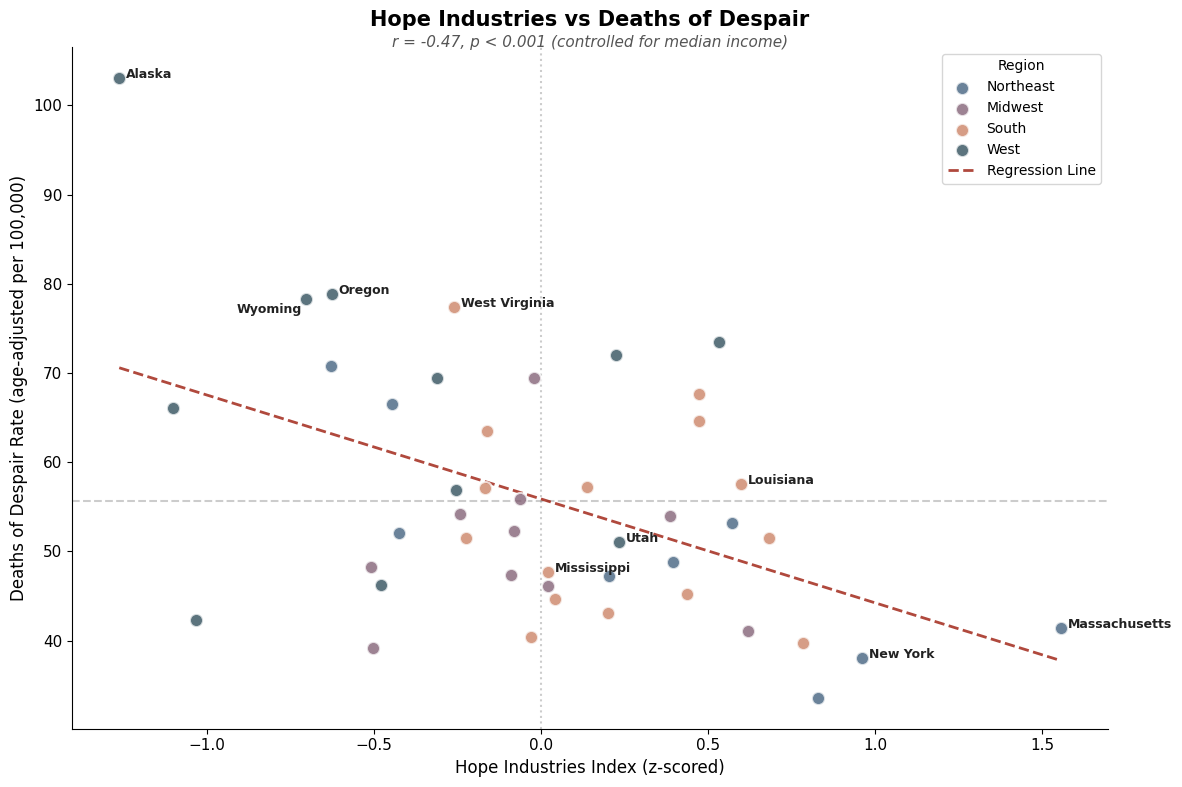

Saved!


In [ ]:
# drop rows with Nulls
plot_data = master.dropna(subset=['hope_index', 'despair_rate', 'median_income', 'lottery_per_capita', 'sports_per_capita', 'adherence_percentage']).copy()


# add regions
plot_data['region'] = plot_data['state'].map(region_map)

print(plot_data['region'].value_counts())

region_colors = {
    'Northeast': '#3A5A78',
    'Midwest': '#7D5A6F',
    'South': '#C97C5D',
    'West': DESPAIR
}


# fit a line
x = plot_data['hope_index'].values
y = plot_data['despair_rate'].values
m, b = np.polyfit(x, y, 1)


# line points for plotting
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b


# states ro label
states_to_label = [
    'Alaska', 'New Mexico', 'West Virginia', 'Wyoming', 'Oregon',
    'Massachusetts', 'New York', 'Mississippi', 'Utah', 'Louisiana'
]


# plot
fig, ax = plt.subplots(figsize = (12, 8))


# refrence lines at the means
ax.axhline(y = plot_data['despair_rate'].mean(), color = 'gray', linestyle = '--', alpha = 0.4, zorder = 1)
ax.axvline(x = 0, color = 'gray', linestyle = ':', alpha=  0.4, zorder = 1)


# plot each region separately
for region, color in region_colors.items():
    region_data = plot_data[plot_data['region'] == region]
    ax.scatter(
        region_data['hope_index'],
        region_data['despair_rate'],
        s = 90,
        color = color,
        alpha = 0.75,
        edgecolors = 'white',
        linewidths = 1.5,
        label = region,
        zorder = 3
    )


# regression line
ax.plot(x_line, y_line, color = '#9c1b0c', linewidth = 2, linestyle = '--', alpha = 0.8, zorder = 2,
        label = 'Regression Line')


#label offsets
label_offsets = {
    'Wyoming': (-50, -10)
}


# label specific states
for _, row in plot_data.iterrows():
  if row['state'] in states_to_label:
    offset = label_offsets.get(row['state'], (5, 0)) # default
    ax.annotate(
        row['state'],
        xy = (row['hope_index'], row['despair_rate']),
        xytext = offset,
        textcoords = "offset points",
        fontsize = 9,
        color = '#222222',
        fontweight = 'bold'
    )


# labels and title
ax.set_xlabel('Hope Industries Index (z-scored)', fontsize = 12)
ax.set_ylabel('Deaths of Despair Rate (age-adjusted per 100,000)', fontsize = 12)
ax.set_title('Hope Industries vs Deaths of Despair', fontsize = 15, fontweight = 'bold', pad = 15)


# subtitle
ax.text(0.5, 1.00,
        'r = -0.47, p < 0.001 (controlled for median income)',
        transform=ax.transAxes, fontsize=11, ha='center', style = 'italic', color = '#555555')


# legend
ax.legend(loc='upper right', frameon=True, fontsize=10, title='Region',
          title_fontsize=10, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.show()


#save
fig.savefig('hope_vs_despair.png', dpi=300, bbox_inches='tight')
print('Saved!')

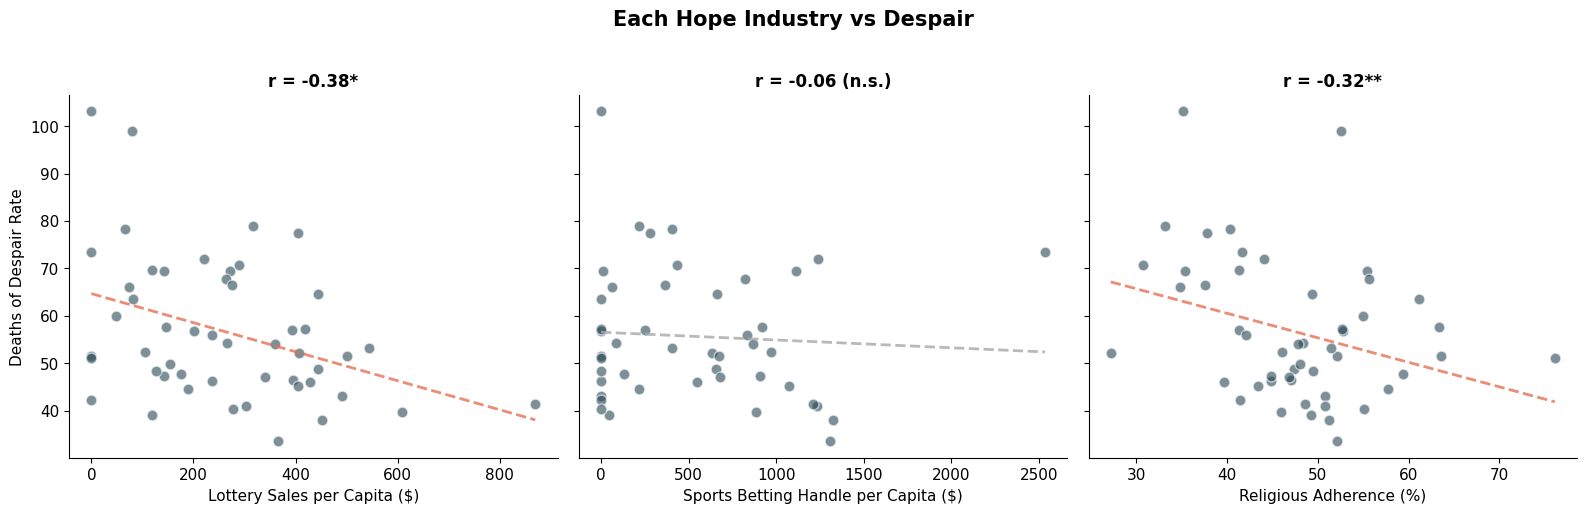

Saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# three subplots
configs = [
    ('lottery_per_capita', 'Lottery Sales per Capita ($)', '-0.38*', ACCENT, axes[0]),
    ('sports_per_capita', 'Sports Betting Handle per Capita ($)', '-0.06 (n.s.)', NEUTRAL, axes[1]),
    ('adherence_percentage', 'Religious Adherence (%)', '-0.32**', ACCENT, axes[2])
]

for col, xlabel, r_value, line_color, ax in configs:
    data = master.dropna(subset = [col, 'despair_rate'])

    ax.scatter(data[col], data['despair_rate'],
               s = 60, alpha = 0.6, color = DESPAIR, edgecolors = 'white', linewidths = 1)

    # regression line
    if len(data) > 1:
        m, b = np.polyfit(data[col], data['despair_rate'], 1)
        x_line = np.linspace(data[col].min(), data[col].max(), 100)
        ax.plot(x_line, m * x_line + b, color = line_color, linestyle='--', linewidth = 2, alpha = 0.8)

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(f'r = {r_value}', fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Deaths of Despair Rate', fontsize = 11)

fig.suptitle('Each Hope Industry vs Despair', fontsize = 15, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.show()


#save
fig.savefig('each_hope_industry.png', dpi=300, bbox_inches='tight')
print('Saved!')


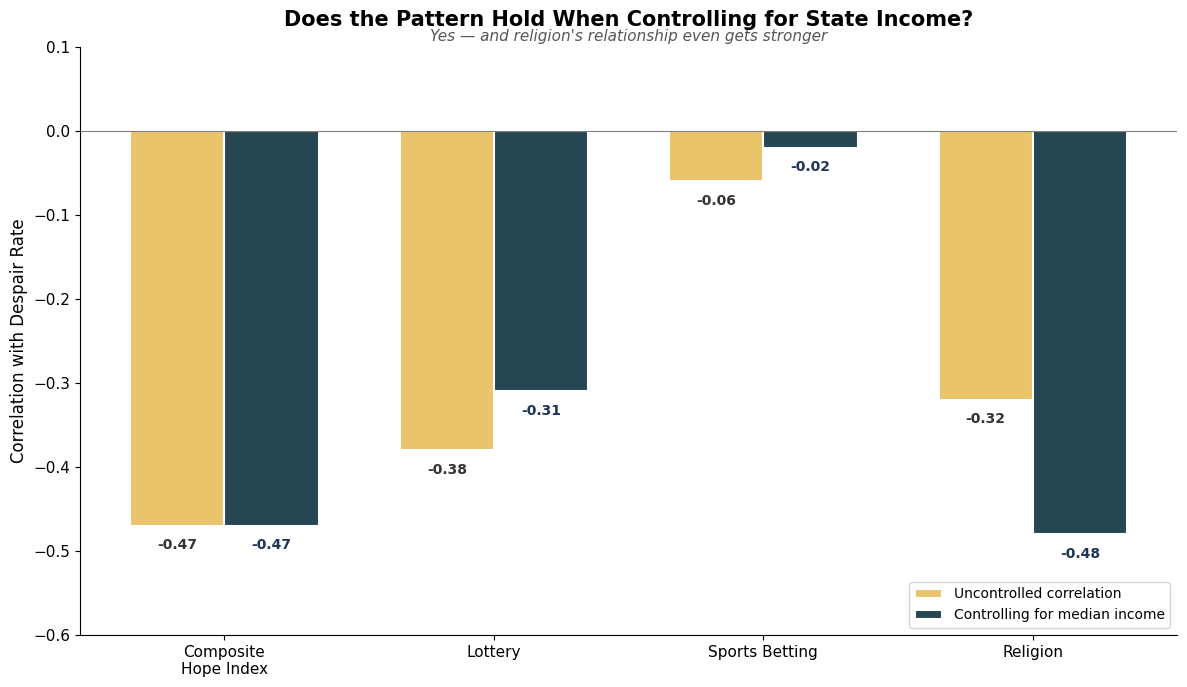

Saved!


In [ ]:
variables = ['Composite\nHope Index', 'Lottery', 'Sports Betting', 'Religion']
uncontrolled = [-0.47, -0.38, -0.06, -0.32]
controlled = [-0.47, -0.31, -0.02, -0.48]

x = np.arange(len(variables))
width = 0.35

fig, ax = plt.subplots(figsize = (12, 7))

# bars
bars1 = ax.bar(x - width/2, uncontrolled, width,
               label ='Uncontrolled correlation',
               color = HOPE, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, controlled, width,
               label ='Controlling for median income',
               color = DESPAIR, edgecolor='white', linewidth=1.5)

# add value labels on each bar
def add_label(bar, color):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height - 0.015,
            f'{height:.2f}',
            ha='center', va='top',
            fontsize=10, color=color, fontweight='bold')

for bar in bars1:
    add_label(bar, '#333333')

for bar in bars2:
    add_label(bar, '#1D3557')


# zero reference line
ax.axhline(y=0, color='gray', linewidth=0.8)

# labels
ax.set_ylabel('Correlation with Despair Rate', fontsize=12)
ax.set_title("Does the Pattern Hold When Controlling for State Income?",
             fontsize=15, fontweight='bold', pad=15)

# subtitle
ax.text(0.5, 1.01,
        "Yes — and religion's relationship even gets stronger",
        transform=ax.transAxes, fontsize=11, ha='center',
        style='italic', color='#555555')

# x-axis
ax.set_xticks(x)
ax.set_xticklabels(variables, fontsize=11)

# legend
ax.legend(loc='lower right', fontsize=10, frameon=True,
          facecolor='white', edgecolor='#cccccc')

# clean up borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# y-axis range — bars are negative, so set limits accordingly
ax.set_ylim(-0.6, 0.1)

plt.tight_layout()

# save before show
fig.savefig('income_control_comparison.png', dpi=300, bbox_inches='tight')

plt.show()
print("Saved!")



States in both lists: {'Nevada'}


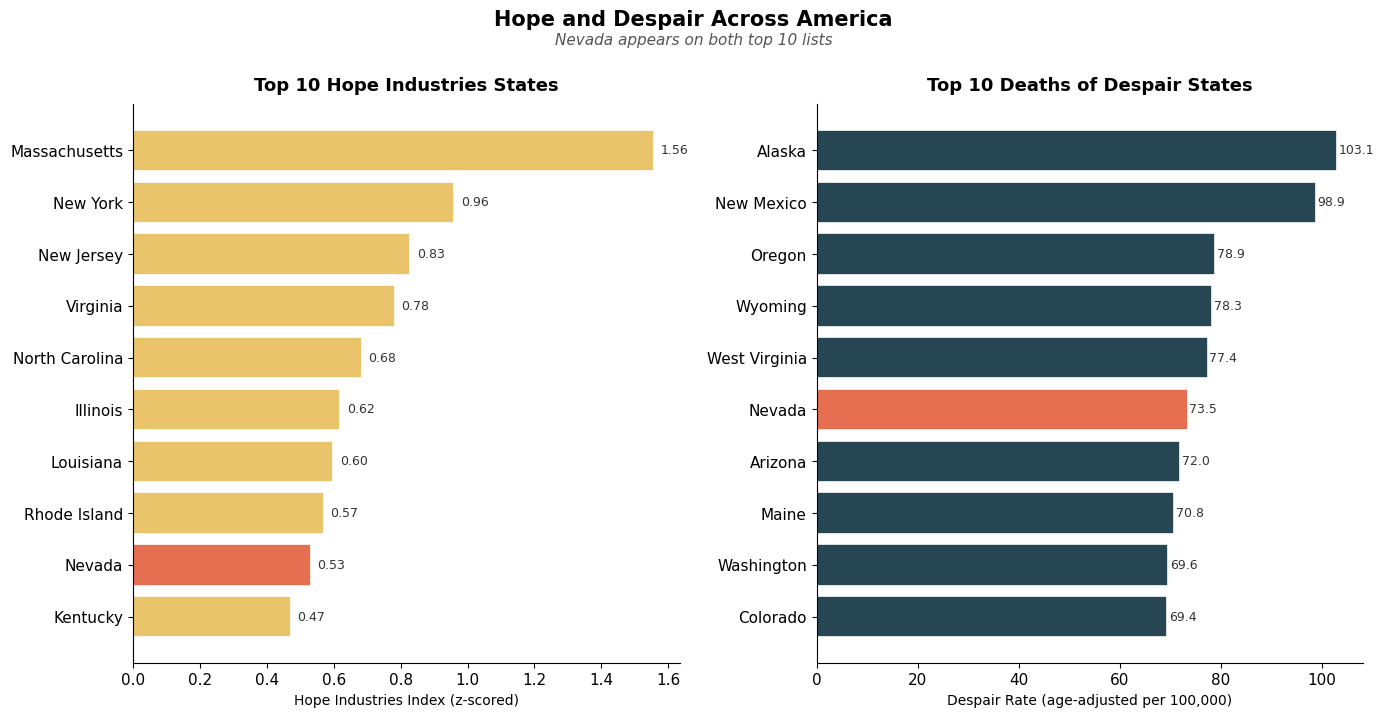

Saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (14, 7))


# left panel: Top 10 Hope Industries States
top_hope = master.dropna(subset=['hope_index']).nlargest(10, 'hope_index')
top_hope = top_hope.sort_values('hope_index', ascending=True)  # ascending for horizontal bar


bars_hope = axes[0].barh(
    top_hope['state'],
    top_hope['hope_index'],
    color = HOPE,
    edgecolor = 'white',
    linewidth = 1.2
)


# add value labels
for bar in bars_hope:
    width = bar.get_width()
    axes[0].text(width + 0.02, bar.get_y() + bar.get_height()/2,
                f'{width:.2f}', va = 'center', ha = 'left', fontsize = 9, color = '#333333')


axes[0].set_title('Top 10 Hope Industries States', fontsize = 13, fontweight = 'bold', pad = 10)
axes[0].set_xlabel('Hope Industries Index (z-scored)', fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].axvline(x = 0, color = 'gray', linewidth = 0.5, linestyle = ':')


# right panel: Top 10 Despair States
top_despair = master.nlargest(10, 'despair_rate')
top_despair = top_despair.sort_values('despair_rate', ascending=True)


bars_despair = axes[1].barh(
    top_despair['state'],
    top_despair['despair_rate'],
    color=DESPAIR,
    edgecolor='white',
    linewidth=1.2
)


# add value labels
for bar in bars_despair:
    width = bar.get_width()
    axes[1].text(width + 0.3, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}', va = 'center', ha = 'left', fontsize = 9, color = '#333333')


axes[1].set_title('Top 10 Deaths of Despair States', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Despair Rate (age-adjusted per 100,000)', fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


# shared title
fig.suptitle('Hope and Despair Across America',
             fontsize=15, fontweight='bold', y=1.02)
fig.text(0.5, 0.97,
         'Nevada appears on both top 10 lists',
         ha='center', fontsize=11, style='italic', color='#555555')


# states appearing in both lists
overlap_states = set(top_hope['state']) & set(top_despair['state'])
print(f"States in both lists: {overlap_states}")


# color overlap states differently
hope_colors = [ACCENT if s in overlap_states else HOPE for s in top_hope['state']]
despair_colors = [ACCENT if s in overlap_states else DESPAIR for s in top_despair['state']]


axes[0].barh(top_hope['state'], top_hope['hope_index'],
             color=hope_colors, edgecolor='white', linewidth=1.2)
axes[1].barh(top_despair['state'], top_despair['despair_rate'],
             color=despair_colors, edgecolor='white', linewidth=1.2)


plt.tight_layout()


# save
fig.savefig('rankings_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved!")


##ArcGIS

In [ ]:
# prepare data for AcrGIS export
arcgis_export = master[[
    'state', 'hope_index', 'despair_rate'
]].copy()


# round for cleaner display in ArcGIS
arcgis_export['hope_index'] = arcgis_export['hope_index'].round(2)
arcgis_export['despair_rate'] = arcgis_export['despair_rate'].round(1)


# vertify
print(f"CSV shape:", arcgis_export.shape)


# export
arcgis_export.to_csv('arcgis_export.csv', index=False)
print(f"\nSaved!")

CSV shape: (50, 3)

Saved!


In [ ]:
# load state shapefile
states_bound = gpd.read_file('tl_2025_us_state.shp')


# states to exclude
exclude = ['Alaska', 'Hawaii', 'Puerto Rico',
           'United States Virgin Islands',
           'Guam', 'Commonwealth of the Northern Mariana Islands',
           'American Samoa']

states_48 = states_bound[~states_bound['NAME'].isin(exclude)].copy()


# join on state name
merged = states_48.merge(arcgis_export,
                         left_on='NAME',
                         right_on='state',
                         how='left'
                         )


# vertify
print(f"Merged rows: {len(merged)}")
print(f"\nFirst few rows:")
print(merged[['NAME', 'hope_index', 'despair_rate']].head(10))



DataSourceError: tl_2025_us_state.shp: No such file or directory

In [ ]:
# Save as shapefile
merged.to_file('merged_states.shp', driver='ESRI Shapefile')

# Zip all components
with zipfile.ZipFile('merged_states.zip', 'w') as zipf:
    for ext in ['.shp', '.dbf', '.shx', '.prj', '.cpg']:
        fname = f'merged_states{ext}'
        if os.path.exists(fname):
            zipf.write(fname)
            print(f"Added: {fname}")

files.download('merged_states.zip')
print("Downloaded!")


In [ ]:
# export merged geodataframe as geojson
merged.to_file('merged_states.geojson', driver='GeoJSON')
files.download('merged_states.geojson')
print(f"\nSaved")